# Principal Component Analysis (PCA)

## What Is PCA?

PCA is a **linear dimensionality reduction technique** that transforms data into a new coordinate system where the axes — called **Principal Components** — are aligned with the directions of maximum variance in the data. The first principal component (PC1) captures the most variance, the second (PC2) captures the next most, and so on, with each component orthogonal to all previous ones.

Mathematically, the transformation is:

$$\mathbf{Z} = \mathbf{X}\mathbf{W}$$

Where $\mathbf{X}$ is the original data matrix, $\mathbf{W}$ is the matrix of principal component vectors (the new axes), and $\mathbf{Z}$ is the transformed, reduced data.

## Intuition

Consider a 2D dataset where the data has a diagonal spread — the natural variation is along a direction that is neither the $x$-axis nor the $y$-axis. The original axes are misaligned with the actual structure of the data.

PCA **rotates the coordinate system** to match the directions of actual spread. After PCA:

- **PC1** points in the direction of maximum variance — it captures as much information as possible in one dimension
- **PC2** points orthogonal to PC1, in the direction of the next highest remaining variance

No data is discarded yet — PCA first finds the best axes, then you decide how many to keep.

## Why Use PCA?

**Dimensionality reduction:** A dataset with 1000 correlated features might be representable with 20 principal components that capture 95% of the variance. Fewer features means faster training, lower memory usage, and less overfitting.

**Visualization:** High-dimensional data cannot be plotted directly. Reducing to 2 or 3 principal components allows you to visualize structure, clusters, and separability.

**Removing multicollinearity:** If features like `height_cm`, `height_m`, and `height_inch` all carry the same information, PCA compresses them into a single independent component. Principal components are by construction **uncorrelated** with each other.

**Noise filtering:** Directions of very low variance typically correspond to noise rather than signal. Discarding the last few principal components effectively denoises the data.

## The Mathematical Derivation

### Step 1: Center the Data

PCA requires the data to be mean-centered. For each feature, subtract its mean:

$$\mathbf{X}_{\text{centered}} = \mathbf{X} - \boldsymbol{\mu}, \qquad \boldsymbol{\mu} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{x}_i$$

This ensures the first principal component passes through the origin and captures variance rather than mean displacement.

### Step 2: Compute the Covariance Matrix

The covariance matrix $\Sigma$ captures how features vary together:

$$\Sigma = \frac{1}{n} \mathbf{X}^T \mathbf{X}$$

For a 2-feature dataset, this is:

$$\Sigma = \begin{bmatrix} \text{var}(x_1) & \text{cov}(x_1, x_2) \\ \text{cov}(x_1, x_2) & \text{var}(x_2) \end{bmatrix}$$

Diagonal entries are the variances of individual features. Off-diagonal entries are the covariances — they measure how much two features change together. High off-diagonal values indicate correlated features that PCA will compress.

### Step 3: Eigen Decomposition

We solve the eigenvalue equation:

$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

Where:

- $\mathbf{v}$ is an **eigenvector** — a direction in the original feature space
- $\lambda$ is the corresponding **eigenvalue** — the amount of variance captured along that direction

Each eigenvector–eigenvalue pair defines one candidate axis. The eigenvector with the largest eigenvalue is the direction of greatest variance — this becomes PC1.

### Step 4: Sort and Select

Sort the eigenvalues in descending order:

$$\lambda_1 \geq \lambda_2 \geq \lambda_3 \geq \cdots \geq \lambda_d$$

The corresponding sorted eigenvectors are:

$$\mathbf{v}_1,\ \mathbf{v}_2,\ \mathbf{v}_3,\ \ldots,\ \mathbf{v}_d$$

These are the principal components. To keep $k$ dimensions, take the top $k$ eigenvectors and form the projection matrix:

$$\mathbf{W} = \begin{bmatrix} \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_k \end{bmatrix}$$

### Step 5: Project the Data

Transform the original data into the new $k$-dimensional space:

$$\mathbf{Z} = \mathbf{X}_{\text{centered}} \cdot \mathbf{W}$$

The result $\mathbf{Z}$ has shape $(n \times k)$ instead of $(n \times d)$. Information has been compressed — the $k$ retained components capture the dominant structure, while the discarded components (low eigenvalue directions) are assumed to carry mostly noise.

## Explained Variance Ratio

The **explained variance ratio** of component $k$ is the fraction of total variance it captures:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{d} \lambda_j}$$

For example, if the output is $[0.95,\ 0.05]$, it means PC1 captures 95% of the total variance and PC2 captures the remaining 5%. In this case, reducing to 1 dimension loses almost no information.

A **cumulative explained variance plot** — plotting $\sum_{j=1}^{k} \text{EVR}_j$ against $k$ — shows how many components are needed to retain a desired fraction of variance (e.g. 95%). This is the standard method for choosing $k$.

## Reconstruction and Information Loss

Since PCA is a linear projection, an approximate reconstruction of the original data is possible:

$$\mathbf{X}_{\text{approx}} = \mathbf{Z} \cdot \mathbf{W}^T + \boldsymbol{\mu}$$

The reconstruction is not perfect unless all components are retained. The reconstruction error is exactly the variance discarded — the sum of the eigenvalues of the dropped components. This provides a precise, quantifiable measure of how much information is lost at any given compression level.

## The Full PCA Algorithm

1. **Standardize** the data — subtract mean and divide by standard deviation per feature
2. **Compute** the covariance matrix $\Sigma = \frac{1}{n}\mathbf{X}^T\mathbf{X}$
3. **Compute** eigenvectors and eigenvalues of $\Sigma$
4. **Sort** eigenvectors by descending eigenvalue
5. **Select** the top $k$ eigenvectors to form $\mathbf{W}$
6. **Project** the data: $\mathbf{Z} = \mathbf{X}_{\text{centered}} \cdot \mathbf{W}$

Standardization in Step 1 is critical. Without it, features measured on larger scales (e.g. income in thousands vs. age in years) will dominate the covariance matrix simply because of their units, not their importance.

## PCA vs Feature Selection

These are two different philosophies for reducing dimensionality:

| Method | Mechanism | Output |
|---|---|---|
| Feature Selection | Keeps a subset of original features | Original, interpretable features |
| PCA | Creates new features as linear combinations | Principal components — abstract, not directly interpretable |

PCA components like PC1, PC2, PC3 are weighted combinations of all original features. You cannot say "PC1 is income" — it is a direction in the full feature space. This loss of interpretability is the main practical tradeoff of PCA versus feature selection.

## Limitations

PCA assumes that **variance equals importance** — that directions of high spread carry signal, and directions of low spread carry noise. This is often but not always true. In some problems, the most discriminative direction may not be the one of highest variance.

PCA also assumes **linear structure**. It finds linear combinations of features. If the data lives on a curved, nonlinear manifold, PCA will produce a poor representation.

| Situation | Better Alternative |
|---|---|
| Nonlinear structure | Kernel PCA |
| Visualization only | t-SNE, UMAP |
| Manifold learning | UMAP, Isomap |

## Big Picture

PCA answers a single question: **given that I must represent my data in fewer dimensions, which directions preserve the most information?**

It rotates the coordinate system to align with the axes of maximum variance, then discards the least informative directions. Everything else — clustering, classification, regression — can then operate in a cleaner, lower-dimensional space.

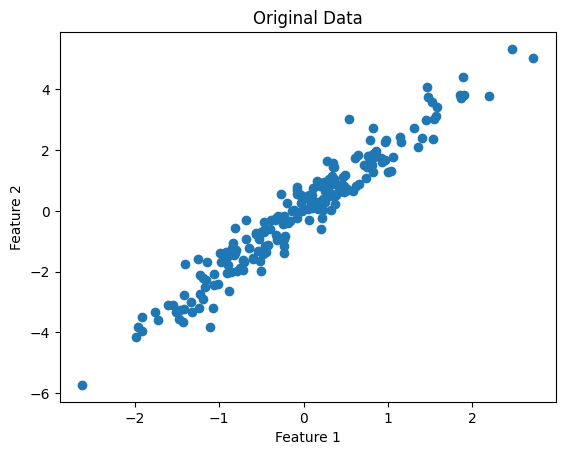

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

x = np.random.normal(0,1,200)
y = 2*x + np.random.normal(0,0.5,200)

X = np.column_stack((x,y))

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [3]:
print(pca.explained_variance_ratio_)

[0.98422279 0.01577721]


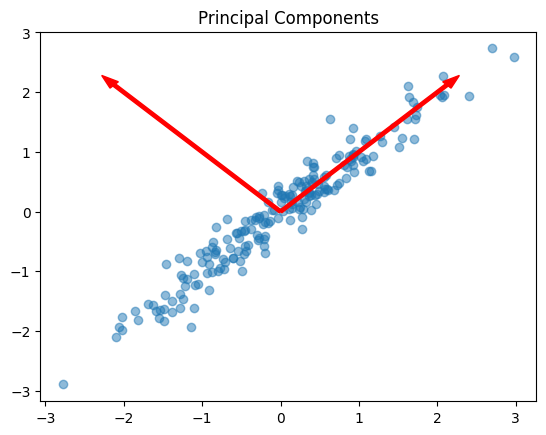

In [4]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], alpha=0.5)

vectors = pca.components_

origin = np.mean(X_scaled, axis=0)

for vector in vectors:
    plt.arrow(origin[0], origin[1],
              vector[0]*3,
              vector[1]*3,
              color='red',
              width=0.05)

plt.title("Principal Components")
plt.show()

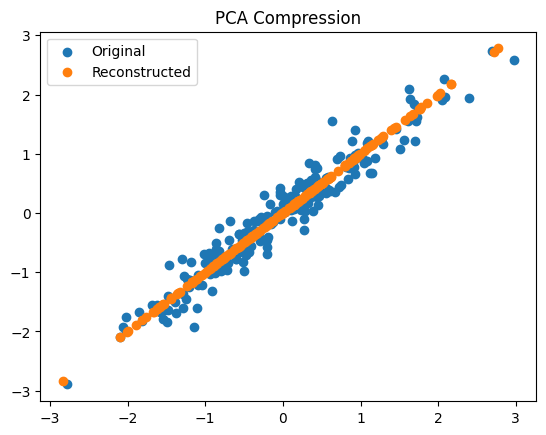

In [5]:
# Reduction to 1 dimension

pca = PCA(n_components=1)

X_reduced = pca.fit_transform(X_scaled)

X_approx = pca.inverse_transform(X_reduced)

plt.scatter(X_scaled[:,0], X_scaled[:,1], label="Original")
plt.scatter(X_approx[:,0], X_approx[:,1], label="Reconstructed")

plt.legend()
plt.title("PCA Compression")
plt.show()

In [6]:
# Working on a real dataset

from sklearn.datasets import load_wine

data = load_wine()

X = data.data
y = data.target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

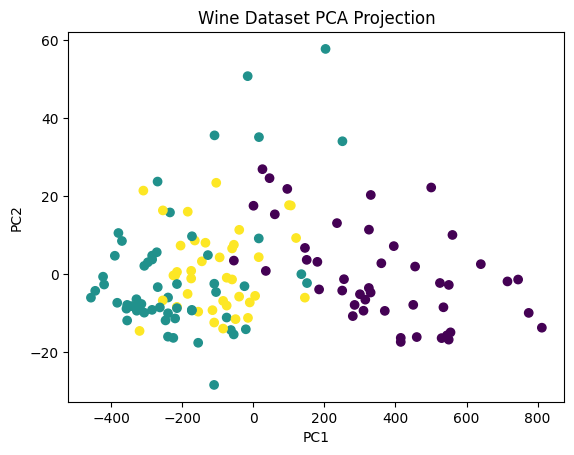

In [8]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset PCA Projection")

plt.show()

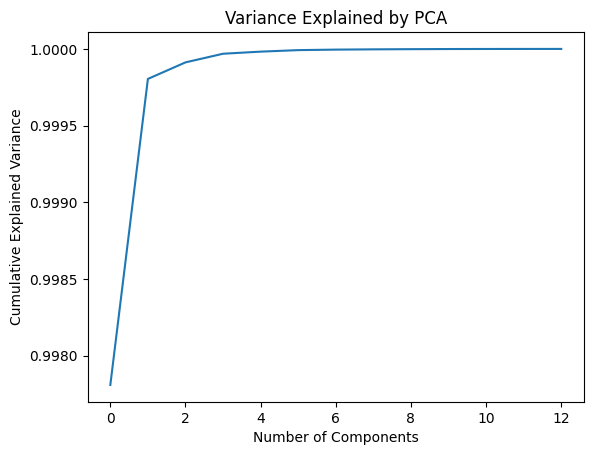

In [9]:
pca = PCA()

pca.fit(X_train)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_)
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Variance Explained by PCA")

plt.show()